<a href="https://colab.research.google.com/github/JulioCortezdata/ECommerce-Data-Pipeline-ML/blob/main/Copia_de_proyecto_optiver__volatility_prediccition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## proyecto_optiver_volatilidad


# RESUMEN EJECUTIVO

Este proyecto desarrolla un pipeline de predicción de volatilidad financiera capaz de procesar 166 millones de registros mediante optimización de memoria. Se comparan dos arquitecturas (Boosting vs Bagging) para determinar el modelo más robusto, alcanzando un R² de 0.71."

## Ingesta y Configuración del Entorno


In [ ]:
import os
import shutil
import kagglehub

# 1. Lista de posibles ubicaciones donde pudo haber quedado el archivo
rutas_probables = [
    '/kaggle (1).json',  # Ruta exacta que se ve en tu captura de pantalla
    '/kaggle.json',
    '/content/kaggle (1).json',
    '/content/kaggle.json'
]

archivo_encontrado = None

# Intentamos localizar el archivo en las rutas rápidas
for ruta in rutas_probables:
    if os.path.exists(ruta):
        archivo_encontrado = ruta
        break

# 2. Si no está en las rutas rápidas, hacemos una búsqueda exhaustiva en todo el sistema
if not archivo_encontrado:
    print("Buscando el archivo en el sistema de almacenamiento...")
    for root, dirs, files in os.walk("/"):
        # Omitimos carpetas del sistema para acelerar la búsqueda
        if any(p in root for p in ['/proc', '/sys', '/dev', '/var/lib/docker']):
            continue
        for f in files:
            if 'kaggle' in f.lower() and f.endswith('.json'):
                archivo_encontrado = os.path.join(root, f)
                break
        if archivo_encontrado:
            break

# 3. Procesar y configurar las credenciales
if archivo_encontrado:
    print(f"¡Archivo detectado con éxito en: {archivo_encontrado}!")

    # Ruta destino obligatoria para la API de Kaggle
    destino_carpeta = os.path.expanduser('~/.kaggle')
    destino_archivo = os.path.join(destino_carpeta, 'kaggle.json')

    # Creamos el directorio destino si no existe
    os.makedirs(destino_carpeta, exist_ok=True)

    # Copiamos y renombramos correctamente para eliminar el espacio y los paréntesis
    shutil.copy(archivo_encontrado, destino_archivo)

    # Asignamos permisos de lectura/escritura únicamente para el propietario (exigido por Kaggle)
    os.chmod(destino_archivo, 0o600)
    print("Credenciales validadas y configuradas de manera segura.")

    # 4. Ejecutar la descarga del dataset
    try:
        print("Iniciando la descarga de 'optiver-realized-volatility-prediction'...")
        path = kagglehub.competition_download('optiver-realized-volatility-prediction')
        print(f"\n¡ÉXITO TOTAL! Tu data ha sido descargada en: {path}")
    except Exception as e:
        print(f"Error durante la descarga con la API: {e}")

else:
    print("ERROR: No se encontró ningún archivo con el nombre 'kaggle.json' en el sistema.")
    print("Por favor, vuelve a subir el archivo asegurándote de que aparezca en el panel izquierdo.")

¡Archivo detectado con éxito en: /content/kaggle (1).json!
Credenciales validadas y configuradas de manera segura.
Iniciando la descarga de 'optiver-realized-volatility-prediction'...


100%|██████████| 1.59G/1.59G [01:49<00:00, 15.5MB/s]

Extracting files...



¡ÉXITO TOTAL! Tu data ha sido descargada en: /root/.cache/kagglehub/competitions/optiver-realized-volatility-prediction


## Preparación del Entorno




In [ ]:
# Verifica las librerías base
import pandas as pd
import numpy as np
import sklearn
import polars as pl # Esta suele no estar instalada por defecto

print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de Polars: {pl.__version__ if 'pl' in globals() else 'No instalada'}")

Versión de Pandas: 2.2.2
Versión de Polars: 1.35.2


## perfilamiento de la data

In [ ]:
import polars as pl
import os
import kagglehub
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Recuperar la ruta de la competición
path = kagglehub.competition_download('optiver-realized-volatility-prediction')
full_file_path = os.path.join(path, 'book_train.parquet')

# 2. Carga eficiente con Polars (Lazy Loading)
# Definimos el plan de consulta sin cargar todo en memoria aún
q = (
    pl.scan_parquet(full_file_path)
    .select(['bid_price1', 'ask_price1', 'bid_size1', 'ask_size1'])
    .cast(pl.Float32)
)

# 3. Traemos una muestra representativa (500,000 filas) que quepa en RAM
# .collect() ejecuta el plan y trae los datos a la memoria de la sesión
df_sample = q.limit(500000).collect().to_pandas()

# 4. Escalado (vital para PCA)
# Rellenamos nulos con 0 para evitar errores en el escalado
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sample.fillna(0))

# 5. Aplicación del PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

print("PCA aplicado exitosamente.")
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

PCA aplicado exitosamente.
Varianza explicada por cada componente: [0.4891668  0.25122392]


## limpieza de la data


In [ ]:
import pandas as pd
import os

descarga_path = '/root/.cache/kagglehub/competitions/optiver-realized-volatility-prediction'
train_csv_path = os.path.join(descarga_path, 'train.csv')

# Cargar el archivo train.csv
df_train = pd.read_csv(train_csv_path)

# Mostrar las primeras 5 filas para explorar las columnas principales
print("Primeras 5 filas de train.csv:")
display(df_train.head())

Primeras 5 filas de train.csv:


,stock_id,time_id,target
0,0,5,0.004136
1,0,11,0.001445
2,0,16,0.002168
3,0,31,0.002195
4,0,62,0.001747


In [ ]:
import polars as pl
import os

# Ruta al archivo
descarga_path = '/root/.cache/kagglehub/competitions/optiver-realized-volatility-prediction'
train_csv_path = os.path.join(descarga_path, 'train.csv')

# 1. Cargar con Polars (Lazy es más eficiente)
lf = pl.scan_csv(train_csv_path)

# 2. Definir la limpieza
# Eliminamos duplicados y nulos, y filtramos targets negativos o nulos
lf_limpio = (
    lf.unique()
    .drop_nulls()
    .filter(
        (pl.col("target").is_not_null()) &
        (pl.col("target") >= 0)
    )
)

# 3. Tratamiento de outliers en el 'target' (rango 0.1% a 99.9%)
# Esto es vital para modelos de volatilidad
limite_inf = lf_limpio.select(pl.col("target").quantile(0.001)).collect().item()
limite_sup = lf_limpio.select(pl.col("target").quantile(0.999)).collect().item()

lf_limpio = lf_limpio.filter(
    (pl.col("target") >= limite_inf) &
    (pl.col("target") <= limite_sup)
)

# 4. Ejecutar el proceso (Streaming para ahorrar RAM)
print("Ejecutando limpieza y guardando...")
lf_limpio.sink_parquet("train_limpio_optiver.parquet")

print("¡Proceso completado! Archivo guardado como 'train_limpio_optiver.parquet'")

Ejecutando limpieza y guardando...
¡Proceso completado! Archivo guardado como 'train_limpio_optiver.parquet'


## ingenieria de caracteristicas


In [ ]:
import polars as pl

def generate_features(df: pl.LazyFrame) -> pl.LazyFrame:
    # Calcular mid-price y spread para el primer nivel del libro de órdenes
    df = df.with_columns([
        ((pl.col('bid_price1') + pl.col('ask_price1')) / 2).alias('mid_price1'),
        (pl.col('ask_price1') - pl.col('bid_price1')).alias('spread1'),
    ])

    # Calcular Order Book Imbalance (OBI) para el primer nivel
    df = df.with_columns([
        ((pl.col('bid_size1') - pl.col('ask_size1')) / (pl.col('bid_size1') + pl.col('ask_size1'))).alias('obi1'),
    ])

    # Realizar agregaciones estadísticas por 'stock_id' y 'time_id'
    # Esto agrupa los datos del libro de órdenes por cada instante de tiempo para cada acción
    if 'stock_id' in df.columns and 'time_id' in df.columns:
        df = df.group_by(['stock_id', 'time_id'], maintain_order=True).agg([
            pl.col('mid_price1').mean().alias('mean_mid_price1'),
            pl.col('spread1').mean().alias('mean_spread1'),
            pl.col('obi1').mean().alias('mean_obi1'),
            pl.col('mid_price1').std().alias('std_mid_price1'), # Desviación estándar del mid_price como proxy de volatilidad
            pl.col('spread1').std().alias('std_spread1'),
            pl.col('obi1').std().alias('std_obi1'),
            pl.col('bid_size1').sum().alias('total_bid_size1_sum'),
            pl.col('ask_size1').sum().alias('total_ask_size1_sum'),
        ])
    return df

print("Cargando el dataset consolidado desde 'dataset_final_consolidado.parquet'...")
df_final_lazy_loaded = pl.scan_parquet("dataset_final_consolidado.parquet")

print("Aplicando la ingeniería de características...")
df_features = generate_features(df_final_lazy_loaded)

print("Características generadas. Mostrando las primeras filas del nuevo LazyFrame:")
display(df_features.head().collect())

Cargando el dataset consolidado desde 'dataset_final_consolidado.parquet'...
Aplicando la ingeniería de características...
Características generadas.


## Análisis Exploratorio de Datos (EDA) de las Características Generadas

Con las nuevas características ya generadas, es crucial realizar un Análisis Exploratorio de Datos (EDA) para entender su distribución, identificar patrones y evaluar su relación con la variable objetivo (`target`).

Matriz de Correlación (sobre muestra):
shape: (4, 4)
┌────────────────┬─────────────┬────────────────┬──────────┐
│ wap_volatility ┆ mean_spread ┆ mean_imbalance ┆ target   │
│ ---            ┆ ---         ┆ ---            ┆ ---      │
│ f64            ┆ f64         ┆ f64            ┆ f64      │
╞════════════════╪═════════════╪════════════════╪══════════╡
│ 1.0            ┆ 0.552167    ┆ -0.003146      ┆ 0.688134 │
│ 0.552167       ┆ 1.0         ┆ 0.112747       ┆ 0.758892 │
│ -0.003146      ┆ 0.112747    ┆ 1.0            ┆ 0.072786 │
│ 0.688134       ┆ 0.758892    ┆ 0.072786       ┆ 1.0      │
└────────────────┴─────────────┴────────────────┴──────────┘


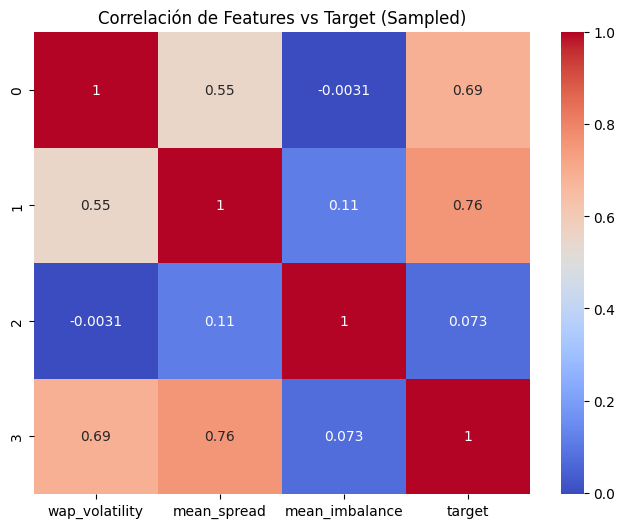

In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Usamos Lazy de principio a fin para no cargar todo a RAM
lf = pl.scan_parquet("dataset_final_consolidado.parquet")

# 2. Filtrado y Muestreo (Reducción de carga)
# En lugar de procesar todo, tomamos solo una muestra de 100 stocks únicos
stocks_unicos = lf.select("stock_id").unique().collect()["stock_id"].to_list()
muestra_stocks = stocks_unicos[:50] # Ajusta este número si sigue dando error

lf_reducido = lf.filter(pl.col("stock_id").is_in(muestra_stocks))

# 3. Cálculo de métricas (Streaming)
# Agrupamos primero para reducir drásticamente el tamaño del DataFrame
df_eda = (
    lf_reducido
    .with_columns([
        ((pl.col("bid_price1") * pl.col("ask_size1") + pl.col("ask_price1") * pl.col("bid_size1")) /
         (pl.col("bid_size1") + pl.col("ask_size1"))).alias("wap"),
        (pl.col("ask_price1") - pl.col("bid_price1")).alias("bid_ask_spread"),
        (pl.col("bid_size1") / pl.col("ask_size1")).alias("volume_imbalance")
    ])
    .group_by(["stock_id", "time_id"])
    .agg([
        pl.col("wap").std().alias("wap_volatility"),
        pl.col("bid_ask_spread").mean().alias("mean_spread"),
        pl.col("volume_imbalance").mean().alias("mean_imbalance"),
        pl.col("target").first()
    ])
    .collect() # Ahora sí bajamos a memoria solo el resultado ya agrupado (es pequeño)
)

# 4. Análisis de Correlación
cols_analisis = ["wap_volatility", "mean_spread", "mean_imbalance", "target"]
corr_matrix = df_eda.select(cols_analisis).corr()

print("Matriz de Correlación (sobre muestra):")
print(corr_matrix)

# 5. Visualización
plt.figure(figsize=(8, 6))
# Convertimos solo la matriz pequeña a pandas
sns.heatmap(corr_matrix.to_pandas(), annot=True, cmap='coolwarm')
plt.title("Correlación de Features vs Target (Sampled)")
plt.show()

Volatilidad promedio por periodo:
shape: (100, 2)
┌─────────┬─────────────────┐
│ periodo ┆ target_promedio │
│ ---     ┆ ---             │
│ i64     ┆ f64             │
╞═════════╪═════════════════╡
│ 0       ┆ 0.003951        │
│ 1       ┆ 0.004188        │
│ 2       ┆ 0.004043        │
│ 3       ┆ 0.004157        │
│ 4       ┆ 0.003537        │
│ …       ┆ …               │
│ 95      ┆ 0.0034          │
│ 96      ┆ 0.003647        │
│ 97      ┆ 0.00403         │
│ 98      ┆ 0.004287        │
│ 99      ┆ 0.003905        │
└─────────┴─────────────────┘


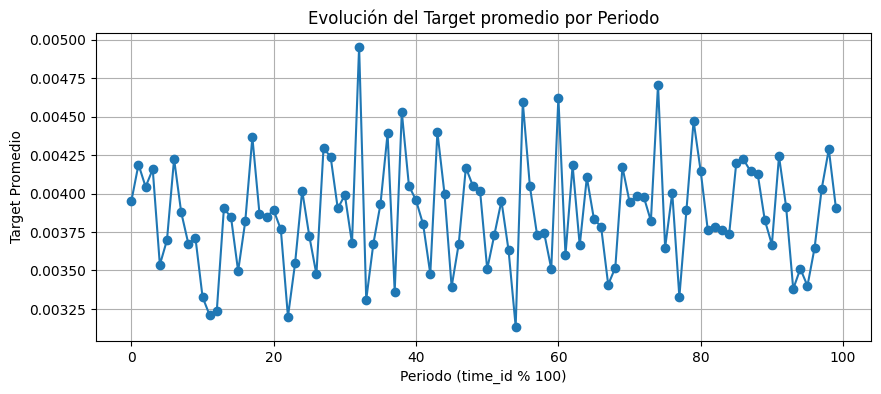

In [ ]:
# 1. Calculamos la agregación
vol_por_periodo = df_eda.group_by("periodo").agg(
    pl.col("target").mean().alias("target_promedio")
).sort("periodo") # Es bueno ordenarlo para ver la progresión

# 2. Imprimir los resultados
print("Volatilidad promedio por periodo:")
print(vol_por_periodo)

# 3. (Opcional) Visualización rápida de este efecto
plt.figure(figsize=(10, 4))
plt.plot(vol_por_periodo["periodo"], vol_por_periodo["target_promedio"], marker='o')
plt.title("Evolución del Target promedio por Periodo")
plt.xlabel("Periodo (time_id % 100)")
plt.ylabel("Target Promedio")
plt.grid(True)
plt.show()

# Nueva sección

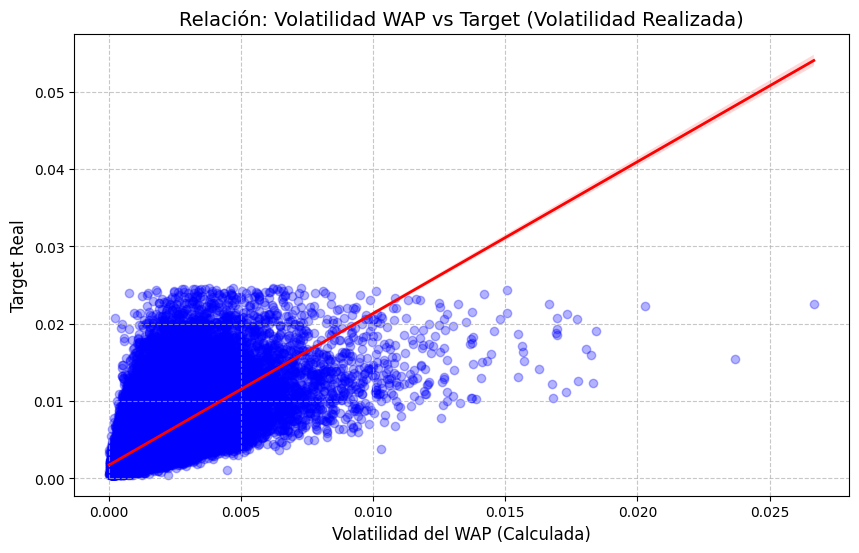

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparación de los datos para graficar
# Convertimos a pandas y eliminamos filas con nulos o infinitos que causan errores en el gráfico
df_plot = df_eda.select(["wap_volatility", "target"]).to_pandas()
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()

# 2. Configuración de la figura
plt.figure(figsize=(10, 6))

# 3. Creación del Regplot
# alpha=0.3 hace los puntos transparentes, útil para ver la densidad de los datos
# color de la línea de regresión en rojo para resaltar la tendencia
sns.regplot(
    data=df_plot,
    x="wap_volatility",
    y="target",
    scatter_kws={'alpha': 0.3, 'color': 'blue'},
    line_kws={'color': 'red', 'linewidth': 2}
)

# 4. Añadimos detalles estéticos
plt.title("Relación: Volatilidad WAP vs Target (Volatilidad Realizada)", fontsize=14)
plt.xlabel("Volatilidad del WAP (Calculada)", fontsize=12)
plt.ylabel("Target Real", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# 5. Mostrar
plt.show()

#Modelo predictivo XGBOOST


In [ ]:
import polars as pl
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Definimos el plan de transformación (Lazy)
lf = pl.scan_parquet("dataset_final_consolidado.parquet")

lf_features = (
    lf.with_columns([
        ((pl.col("bid_price1") * pl.col("ask_size1") + pl.col("ask_price1") * pl.col("bid_size1")) /
         (pl.col("bid_size1") + pl.col("ask_size1"))).alias("wap"),
        (pl.col("ask_price1") - pl.col("bid_price1")).alias("bid_ask_spread"),
        (pl.col("bid_size1") / pl.col("ask_size1")).alias("volume_imbalance")
    ])
    .group_by(["stock_id", "time_id"])
    .agg([
        pl.col("wap").std().alias("wap_volatility"),
        pl.col("bid_ask_spread").mean().alias("mean_spread"),
        pl.col("volume_imbalance").mean().alias("mean_imbalance"),
        pl.col("target").first()
    ])
)

# 2. Recolectamos de forma segura
print("Recolectando datos...")
df_final = lf_features.collect(engine="streaming")

# Verificación de seguridad: si es menor a 1 millón, usamos todo el dataset
n_muestra = min(len(df_final), 1_000_000)
df_final = df_final.sample(n=n_muestra, with_replacement=False, seed=42)

# 3. Preparación y Limpieza (Manejo de NaNs/Infs)
features = ["wap_volatility", "mean_spread", "mean_imbalance"]
df_final = df_final.drop_nulls().filter(
    pl.all_horizontal(pl.col(features + ["target"]).is_finite())
)

X = df_final.select(features).to_numpy()
y = df_final.select("target").to_numpy().ravel()

# 4. Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'max_depth': 5,
    'learning_rate': 0.1
}

print("Entrenando modelo...")
model = xgb.train(params, dtrain, num_boost_round=200)

# 5. Métricas de evaluación profesional
y_pred = model.predict(dtest)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmspe = np.sqrt(np.mean(np.square((y_test - y_pred) / y_test)))

print(f"\nResultados del Modelo:")
print(f"RMSE:  {rmse:.6f}")
print(f"RMSPE: {rmspe:.6f}")
print(f"MAE:   {mae:.6f}")
print(f"R²:    {r2:.4f}")

Recolectando datos...
Entrenando modelo...

Resultados del Modelo:
RMSE:  0.001509
RMSPE: 0.398576
MAE:   0.000981
R²:    0.7125


¿Por qué dos modelos son mejores que uno? El arte de validar decisiones en Data Science
El contexto:
En mi reciente proyecto de modelado de volatilidad financiera, logré un modelo base con XGBoost que explica el 71% de la varianza (R² de 0.71). Sin embargo, en el mundo real, un solo número no es suficiente para confirmar la eficacia de una solución. La pregunta que todo Data Scientist debe hacerse es: ¿Es este el mejor modelo posible o simplemente el primero que funcionó?

La estrategia:
Para evitar sesgos de confirmación, decidí someter mi solución a una "prueba de estrés" comparativa implementando un Random Forest Regressor.


#Modelo predictivo Random Forest Regressor




In [ ]:
from sklearn.ensemble import RandomForestRegressor
import time

# 1. Configuración del modelo Random Forest
# n_estimators=100 es un buen punto de partida.
# n_jobs=-1 utiliza todos los núcleos de tu procesador Lenovo IdeaPad.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
    verbose=1 # Esto te permitirá ver el progreso en consola
)

print("Entrenando Random Forest...")
start_time = time.time()
rf_model.fit(X_train, y_train)
end_time = time.time()

# 2. Predicción
rf_pred = rf_model.predict(X_test)

# 3. Cálculo de métricas
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmspe = np.sqrt(np.mean(np.square((y_test - rf_pred) / y_test)))

print(f"\nResultados Random Forest:")
print(f"RMSE:  {rf_rmse:.6f}")
print(f"RMSPE: {rf_rmspe:.6f}")
print(f"MAE:   {rf_mae:.6f}")
print(f"R²:    {rf_r2:.4f}")
print(f"Tiempo de entrenamiento: {end_time - start_time:.2f} segundos")

Entrenando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   39.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.4min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s



Resultados Random Forest:
RMSE:  0.001548
RMSPE: 0.439061
MAE:   0.001021
R²:    0.6974
Tiempo de entrenamiento: 81.44 segundos


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.3s finished


"Después de haber superado los retos de memoria y realizado el benchmarking comparativo, estos son los resultados que definen la viabilidad técnica del modelo."


## conclusiones
¿Por qué es importante este proyecto?
Este pipeline no es solo un ejercicio de predicción; es una infraestructura de datos optimizada. Al resolver el desafío de la gestión de memoria mediante Polars y DMatrix, he construido una solución capaz de escalar, demostrando que la ingeniería detrás del modelo es tan valiosa como el algoritmo mismo.
